# Winning Without an xG Advantage
## A Statistical Analysis of Positional Structure in xG-Parity Matches

**Georgia Tech MSA Spring 2026**  
**Team 4:** Alexander Avramov, Noah Boonin, Thomas LaRock  
**Track:** Soccer Analytics Dashboard

---

### Executive Summary

*[Write this LAST after completing all analysis - this is a placeholder]*

This notebook presents a systematic, question-driven analysis of 651 professional soccer matches where both teams created nearly equal expected goals (|ΔxG| ≤ 0.3). Through rigorous statistical testing, we demonstrate that **when chance quality is equal, positional structure separates winners from non-winners**.

**Key Findings:**
1. [Finding 1 with specific numbers and p-value]
2. [Finding 2 with specific numbers and p-value]
3. [Finding 3 with specific numbers and p-value]
4. [Finding 4 with specific numbers and p-value]

**Statistical Rigor:**
- 7 distinct statistical tests applied
- Multiple testing correction (Bonferroni)
- Effect size analysis (Cohen's d)
- Multivariate testing (Hotelling's T²)

**Implications:**
[What this means for coaches, analysts, and tactical understanding]

---

### Setup: Library Imports

In [3]:
import pandas as pd
import numpy as np
import polars as pl
from pathlib import Path

from scipy import stats
from scipy.stats import (
    chi2_contingency,
    mannwhitneyu,
    spearmanr,
    f
)
from numpy.linalg import inv

import matplotlib.pyplot as plt
import seaborn as sns
from mplsoccer import Pitch, VerticalPitch

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 200)
plt.style.use('seaborn-v0_8-darkgrid')

print("Libraries imported successfully")

Libraries imported successfully


### Data Loading

We use **StatsBomb Open Data** containing event-level data from professional soccer matches across multiple competitions and seasons.

**Data Structure:**
- `matches.parquet` - Match-level metadata (teams, scores, competitions)
- `events.parquet` - Event-level data (passes, shots, carries, etc.)
- `lineups.parquet` - Player lineups and positions

In [4]:
# Data directory
DATA_DIR = Path("../data")
STATSBOMB_DIR = DATA_DIR / "Statsbomb"

# Load core datasets
print("Loading StatsBomb data...")
matches = pl.read_parquet(STATSBOMB_DIR / "matches.parquet")
events = pl.read_parquet(STATSBOMB_DIR / "events.parquet")
lineups = pl.read_parquet(STATSBOMB_DIR / "lineups.parquet")

print(f"Loaded {len(matches):,} matches")
print(f"Loaded {len(events):,} events")
print(f"Loaded {len(lineups):,} lineup records")
print(f"\nDataset date range: {matches['match_date'].min()} to {matches['match_date'].max()}")
print(f"Competitions: {matches['competition'].n_unique()} unique competitions")

Loading StatsBomb data...
Loaded 3,464 matches
Loaded 12,188,949 events
Loaded 165,820 lineup records

Dataset date range: 1958-06-24 to 2025-07-27
Competitions: 21 unique competitions


### Data Quality Verification

The StatsBomb event dataset is highly sparse by design, as most columns are event-conditional.
Fields related to shots, goalkeeper actions, substitutions, disciplinary events, and relational links
(e.g., assisted shots) are only populated when the corresponding event type occurs.

As a result, columns such as `shot_statsbomb_xg`, `goalkeeper_*`, and `substitution_*` exhibit high
missingness due to event rarity rather than data quality issues.

Core identifiers, timestamps, team labels, and possession fields show no missingness, confirming the
structural integrity of the dataset. Spatial fields and player metadata are nearly complete, with
minor missingness attributable to off-camera or administrative events.

No global imputation or row-level filtering is required at this stage; subsequent analyses will
filter by event type and operate only on contextually relevant fields.

In [5]:
# Check for missing values in critical fields
print("Data Completeness Check:")
print(f"{'='*60}")

# Matches
missing_matches = matches.select([
    pl.col("match_id").is_null().sum().alias("match_id"),
    pl.col("home_score").is_null().sum().alias("home_score"),
    pl.col("away_score").is_null().sum().alias("away_score"),
])
print(f"Matches - Missing values: {missing_matches}")

# Events
missing_events = events.select([
    pl.col("match_id").is_null().sum().alias("match_id"),
    pl.col("type").is_null().sum().alias("type"),
    pl.col("team").is_null().sum().alias("team"),
])
print(f"Events - Missing values: {missing_events}")

# Check for duplicate match IDs
duplicate_matches = matches.group_by("match_id").agg(pl.len()).filter(pl.col("len") > 1)
print(f"\nDuplicate matches: {len(duplicate_matches)}")

print(f"{'='*60}")
print("Data quality check complete")

Data Completeness Check:
Matches - Missing values: shape: (1, 3)
┌──────────┬────────────┬────────────┐
│ match_id ┆ home_score ┆ away_score │
│ ---      ┆ ---        ┆ ---        │
│ u32      ┆ u32        ┆ u32        │
╞══════════╪════════════╪════════════╡
│ 0        ┆ 0          ┆ 0          │
└──────────┴────────────┴────────────┘
Events - Missing values: shape: (1, 3)
┌──────────┬──────┬──────┐
│ match_id ┆ type ┆ team │
│ ---      ┆ ---  ┆ ---  │
│ u32      ┆ u32  ┆ u32  │
╞══════════╪══════╪══════╡
│ 0        ┆ 0    ┆ 0    │
└──────────┴──────┴──────┘

Duplicate matches: 0
Data quality check complete


# SECTION 1: Validating the xG-Parity Concept

## Question 1: Are xG-parity matches actually "close" matches?

**Research Question:** If xG-parity (|ΔxG| ≤ 0.3) truly represents "close" matches, we should observe:
1. Higher draw rate than in xG-dominant matches
2. More balanced win/loss distribution

**Hypothesis:** Draw rate in xG-parity matches > Draw rate in all matches

**xG Difference Categories:** Parity (≤0.3) | Close (0.3–0.7) | Moderate (0.7–1.5) | Dominant (>1.5)
**Statistical Test:** Chi-square test of independence  
**Null Hypothesis (H₀):** Outcome distribution is independent of xG difference category  
**Alternative Hypothesis (H₁):** xG-parity matches have different outcome distribution

**Expected Result:** χ² p-value < 0.05, with higher draw rate in parity matches

---

In [6]:
# Build match-level xG and outcome data
shots = events.filter(pl.col("type") == "Shot")

team_match_xg = (
    shots
    .group_by(["match_id", "team"])
    .agg(pl.col("shot_statsbomb_xg").sum().alias("total_xg"))
)

# Build team outcomes from match scores
home_outcomes = matches.select([
    pl.col("match_id"),
    pl.col("home_team").alias("team"),
    pl.col("home_score"),
    pl.col("away_score"),
]).with_columns([
    pl.when(pl.col("home_score") > pl.col("away_score")).then(pl.lit("Win"))
      .when(pl.col("home_score") < pl.col("away_score")).then(pl.lit("Loss"))
      .otherwise(pl.lit("Draw")).alias("outcome")
])

away_outcomes = matches.select([
    pl.col("match_id"),
    pl.col("away_team").alias("team"),
    pl.col("home_score"),
    pl.col("away_score"),
]).with_columns([
    pl.when(pl.col("away_score") > pl.col("home_score")).then(pl.lit("Win"))
      .when(pl.col("away_score") < pl.col("home_score")).then(pl.lit("Loss"))
      .otherwise(pl.lit("Draw")).alias("outcome")
])

team_outcomes = pl.concat([
    home_outcomes.select(["match_id", "team", "outcome"]),
    away_outcomes.select(["match_id", "team", "outcome"])
])

team_match_xg = team_match_xg.join(team_outcomes, on=["match_id", "team"], how="left")

# Pivot to one row per match with both teams' xG
xg_wide = (
    team_match_xg
    .join(
        team_match_xg.rename({"team": "opp_team", "total_xg": "opp_xg", "outcome": "opp_outcome"}),
        on="match_id"
    )
    .filter(pl.col("team") != pl.col("opp_team"))
    # Deduplicate to one row per match (home team perspective)
    .join(matches.select(["match_id", pl.col("home_team").alias("team")]), on=["match_id", "team"])
)

xg_wide = xg_wide.with_columns([
    (pl.col("total_xg") - pl.col("opp_xg")).abs().alias("xg_diff")
])

# Assign xG difference buckets
xg_wide = xg_wide.with_columns([
    pl.when(pl.col("xg_diff") <= 0.3).then(pl.lit("Parity (≤0.3)"))
      .when(pl.col("xg_diff") <= 0.7).then(pl.lit("Close (0.3–0.7)"))
      .when(pl.col("xg_diff") <= 1.5).then(pl.lit("Moderate (0.7–1.5)"))
      .otherwise(pl.lit("Dominant (>1.5)")).alias("xg_category")
])

print(f"Match-level observations: {len(xg_wide):,}")
print(f"\nMatches per xG category:")
print(xg_wide.group_by("xg_category").agg(pl.len().alias("count")).sort("count", descending=True))

Match-level observations: 3,457

Matches per xG category:
shape: (4, 2)
┌────────────────────┬───────┐
│ xg_category        ┆ count │
│ ---                ┆ ---   │
│ str                ┆ u32   │
╞════════════════════╪═══════╡
│ Moderate (0.7–1.5) ┆ 1127  │
│ Dominant (>1.5)    ┆ 870   │
│ Close (0.3–0.7)    ┆ 809   │
│ Parity (≤0.3)      ┆ 651   │
└────────────────────┴───────┘


In [7]:
from scipy.stats import chi2_contingency

# Convert to pandas for scipy
df = xg_wide.select(["match_id", "xg_category", "outcome"]).to_pandas()

# Build contingency table: xG category × outcome
contingency = pd.crosstab(df["xg_category"], df["outcome"])

# Define category order for display
cat_order = ["Parity (≤0.3)", "Close (0.3–0.7)", "Moderate (0.7–1.5)", "Dominant (>1.5)"]
contingency = contingency.reindex(cat_order)

# Run chi-square test
chi2, p, dof, expected = chi2_contingency(contingency)

# Add draw rate column for interpretability
contingency["Total"] = contingency.sum(axis=1)
contingency["Draw Rate"] = (contingency["Draw"] / contingency["Total"]).round(3)

print("Contingency Table: Match Outcome by xG Difference Category")
print("=" * 65)
print(contingency.to_string())
print(f"\nChi-Square Test of Independence")
print(f"  χ² statistic : {chi2:.4f}")
print(f"  Degrees of freedom: {dof}")
print(f"  p-value      : {p:.6f}")
print(f"\nInterpretation: {'Reject H₀' if p < 0.05 else 'Fail to reject H₀'} at α = 0.05")

Contingency Table: Match Outcome by xG Difference Category
outcome             Draw  Loss  Win  Total  Draw Rate
xg_category                                          
Parity (≤0.3)        194   204  253    651      0.298
Close (0.3–0.7)      240   263  306    809      0.297
Moderate (0.7–1.5)   266   356  505   1127      0.236
Dominant (>1.5)       97   277  496    870      0.111

Chi-Square Test of Independence
  χ² statistic : 124.4842
  Degrees of freedom: 6
  p-value      : 0.000000

Interpretation: Reject H₀ at α = 0.05


### Finding 1: xG-Parity Matches Are Genuinely Contested

**Statistical Evidence:**
- Test: Chi-square test of independence
- χ² = 124.48, df = 6, p < 0.0001
- Result: Reject H₀ — outcome distribution is not independent of xG category

**Draw Rates by Category:**
| xG Category | Draw Rate |
|-------------|-----------|
| Parity (≤0.3) | 29.8% |
| Close (0.3–0.7) | 29.7% |
| Moderate (0.7–1.5) | 23.6% |
| Dominant (>1.5) | 11.1% |

**Interpretation:**  
Parity and close matches share nearly identical draw rates (~30%), both roughly 3× higher 
than dominant matches (11.1%). The meaningful threshold is not precisely at 0.3 — it falls 
somewhere between 0.7 and 1.5, where one team's xG advantage begins translating reliably 
into wins. Within the parity subset (|ΔxG| ≤ 0.3), outcomes remain genuinely uncertain: 
draws occur in nearly 1 in 3 matches, and no single outcome dominates.

**Decision:** xG-parity matches are validated as genuinely contested 

---

---

# Section 2: Positional Touch Share Analysis

## Question 2: When xG is equal, do winners possess the ball differently across positions?

**Hypothesis:** Winning teams shift possession forward — allocating more touches to attacking 
positions (AM, WF, ST) and fewer to defensive positions (CB, DM) — compared to non-winning teams 
in the same xG-parity matches.

**Approach:** We test this in three layers:
- **2A — Is there a difference?** Mann-Whitney U test by position
- **2B — How big is it?** Cohen's d effect sizes
- **2C — Is it robust?** Bonferroni correction for multiple testing

**Data:** 651 xG-parity matches → 1,302 team-match observations  
**Outcome Groups:** Win vs. Non-Win (Draw + Loss combined)

---

We begin by constructing positional touch share, i.e. the proportion of a team's total touches 
attributed to each positional group within a match. This normalizes for possession volume, 
ensuring we are measuring *where* a team plays rather than *how much* they play. A team 
that dominates possession but concentrates it defensively looks very different from one 
that circulates the ball in advanced areas, even if their total touch counts are similar.

In [15]:
# Define touch event types
TOUCH_EVENTS = ["Ball Receipt*", "Pass", "Carry", "Dribble", "Shot"]

# Position bin mapping
POSITION_BIN_MAP = {
    # Goalkeeper
    "Goalkeeper": "Goalkeeper",
    # Center Backs
    "Center Back": "Center Back",
    "Left Center Back": "Center Back",
    "Right Center Back": "Center Back",
    # Fullbacks
    "Left Back": "Fullback",
    "Right Back": "Fullback",
    "Left Wing Back": "Fullback",
    "Right Wing Back": "Fullback",
    # Defensive Midfield
    "Center Defensive Midfield": "Defensive Midfield",
    "Left Defensive Midfield": "Defensive Midfield",
    "Right Defensive Midfield": "Defensive Midfield",
    # Central Midfield
    "Center Midfield": "Central Midfield",
    "Left Center Midfield": "Central Midfield",
    "Right Center Midfield": "Central Midfield",
    # Attacking Midfield
    "Center Attacking Midfield": "Attacking Midfield",
    "Left Attacking Midfield": "Attacking Midfield",
    "Right Attacking Midfield": "Attacking Midfield",
    # Wide Midfield
    "Left Midfield": "Wide Midfield",
    "Right Midfield": "Wide Midfield",
    # Wide Forward
    "Left Wing": "Wide Forward",
    "Right Wing": "Wide Forward",
    # Striker
    "Center Forward": "Striker",
    "Left Center Forward": "Striker",
    "Right Center Forward": "Striker",
    "Secondary Striker": "Striker",
}

# Filter to xG-parity match IDs
parity_match_ids = (
    xg_wide
    .filter(pl.col("xg_category") == "Parity (≤0.3)")
    .select("match_id")
    .to_series()
    .to_list()
)
print(f"Parity match IDs: {len(parity_match_ids):,}")

# Filter events to touch events in parity matches
touches = (
    events
    .filter(pl.col("match_id").is_in(parity_match_ids))
    .filter(pl.col("type").is_in(TOUCH_EVENTS))
    .filter(pl.col("position").is_not_null())
    .with_columns(
        pl.col("position").replace(POSITION_BIN_MAP).alias("position_bin")
    )
    .filter(pl.col("position_bin").is_not_null())
)

# Aggregate touches by team-match-position
team_match_position_touches = (
    touches
    .group_by(["match_id", "team", "position_bin"])
    .agg(pl.len().alias("touches"))
)

# Compute touch share within each team-match
team_match_totals = (
    team_match_position_touches
    .group_by(["match_id", "team"])
    .agg(pl.col("touches").sum().alias("team_touches"))
)

team_match_position_touches = (
    team_match_position_touches
    .join(team_match_totals, on=["match_id", "team"])
    .with_columns(
        (pl.col("touches") / pl.col("team_touches")).alias("touch_share")
    )
    .join(team_outcomes, on=["match_id", "team"])
    .with_columns(
        pl.when(pl.col("outcome") == "Win")
          .then(pl.lit("Win"))
          .otherwise(pl.lit("Non-Win"))
          .alias("outcome_binary")
    )
)

# Convert to pandas for statistical testing
touches_pd = team_match_position_touches.to_pandas()

print(f"Team-match-position observations: {len(touches_pd):,}")
print(f"Unique positions: {sorted(touches_pd['position_bin'].unique())}")
print(f"\nOutcome distribution:")
print(touches_pd.drop_duplicates(['match_id','team'])['outcome_binary'].value_counts())

Parity match IDs: 651
Team-match-position observations: 9,207
Unique positions: ['Attacking Midfield', 'Center Back', 'Central Midfield', 'Defensive Midfield', 'Fullback', 'Goalkeeper', 'Striker', 'Wide Forward', 'Wide Midfield']

Outcome distribution:
outcome_binary
Non-Win    845
Win        457
Name: count, dtype: int64


We use the Mann-Whitney U test rather than a standard t-test because touch share 
distributions are bounded (between 0 and 1) and right-skewed so they do not meet the 
normality assumption t-tests require. Mann-Whitney tests whether values from one 
group tend to be systematically higher than the other without assuming any particular 
distribution shape. We run it separately for each of the 9 positions, testing whether 
winners and non-winners differ in how they allocate touches at each position.

In [16]:
from scipy.stats import mannwhitneyu

positions = sorted(touches_pd['position_bin'].unique())

wins = touches_pd[touches_pd['outcome_binary'] == 'Win']
nonwins = touches_pd[touches_pd['outcome_binary'] == 'Non-Win']

results = []
for position in positions:
    win_shares = wins[wins['position_bin'] == position]['touch_share']
    nonwin_shares = nonwins[nonwins['position_bin'] == position]['touch_share']
    
    u_stat, p_val = mannwhitneyu(win_shares, nonwin_shares, alternative='two-sided')
    
    win_mean = win_shares.mean()
    nonwin_mean = nonwin_shares.mean()
    diff = win_mean - nonwin_mean
    
    results.append({
        'Position': position,
        'Win Mean': round(win_mean, 4),
        'Non-Win Mean': round(nonwin_mean, 4),
        'Difference': round(diff, 4),
        'U Statistic': round(u_stat, 1),
        'p-value': round(p_val, 4),
        'Significant': '✅' if p_val < 0.05 else '❌'
    })

mw_results = pd.DataFrame(results).sort_values('Difference', ascending=False)
print("Mann-Whitney U Test: Touch Share by Position (Win vs. Non-Win)")
print("=" * 70)
print(mw_results.to_string(index=False))
print(f"\nSignificant positions (p < 0.05): {mw_results['Significant'].eq('✅').sum()}/9")

Mann-Whitney U Test: Touch Share by Position (Win vs. Non-Win)
          Position  Win Mean  Non-Win Mean  Difference  U Statistic  p-value Significant
Attacking Midfield    0.1058        0.0903      0.0155      65242.5   0.0002           ✅
     Wide Midfield    0.1654        0.1528      0.0126      33353.0   0.0429           ✅
      Wide Forward    0.1741        0.1617      0.0124      85302.0   0.0009           ✅
           Striker    0.1171        0.1119      0.0052     201868.5   0.1749           ❌
        Goalkeeper    0.0497        0.0460      0.0038     219014.5   0.0001           ✅
  Central Midfield    0.1782        0.1747      0.0036      68170.0   0.2220           ❌
          Fullback    0.1881        0.1937     -0.0055     171911.0   0.0019           ✅
       Center Back    0.1713        0.1804     -0.0091     174002.0   0.0032           ✅
Defensive Midfield    0.1559        0.1666     -0.0107     149582.0   0.0051           ✅

Significant positions (p < 0.05): 7/9


A statistically significant p-value tells us a difference exists, but not whether it 
matters in practice. With over 1,300 team-match observations, even trivially small 
differences can reach significance. Cohen's d measures effect size or the magnitude of 
the difference relative to natural variation in the data. Convention classifies effects 
as negligible (d < 0.2), small (0.2–0.5), medium (0.5–0.8), or large (> 0.8).

In [17]:
def cohens_d(group1, group2):
    n1, n2 = len(group1), len(group2)
    var1, var2 = group1.var(ddof=1), group2.var(ddof=1)
    pooled_std = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    return (group1.mean() - group2.mean()) / pooled_std

effect_sizes = []
for position in positions:
    win_shares = wins[wins['position_bin'] == position]['touch_share']
    nonwin_shares = nonwins[nonwins['position_bin'] == position]['touch_share']
    
    d = cohens_d(win_shares, nonwin_shares)
    
    if abs(d) >= 0.8:
        magnitude = 'Large'
    elif abs(d) >= 0.5:
        magnitude = 'Medium'
    elif abs(d) >= 0.2:
        magnitude = 'Small'
    else:
        magnitude = 'Negligible'
    
    effect_sizes.append({
        'Position': position,
        'Cohen\'s d': round(d, 4),
        'Magnitude': magnitude,
    })

cd_results = pd.DataFrame(effect_sizes).sort_values('Cohen\'s d', ascending=False)
print("Cohen's d Effect Sizes: Touch Share by Position (Win vs. Non-Win)")
print("=" * 55)
print(cd_results.to_string(index=False))

Cohen's d Effect Sizes: Touch Share by Position (Win vs. Non-Win)
          Position  Cohen's d  Magnitude
Attacking Midfield     0.3527      Small
      Wide Forward     0.2106      Small
        Goalkeeper     0.2028      Small
     Wide Midfield     0.1688 Negligible
           Striker     0.1018 Negligible
  Central Midfield     0.0508 Negligible
       Center Back    -0.1456 Negligible
Defensive Midfield    -0.1767 Negligible
          Fullback    -0.1866 Negligible


Testing 9 positions simultaneously inflates our false positive risk. If each test has a 
5% chance of a false positive, running 9 tests means we'd expect roughly one spurious 
significant result by chance alone. Bonferroni correction addresses this by tightening 
the significance threshold by dividing α = 0.05 by the number of tests (9), giving an 
adjusted threshold of 0.0056. Positions that survive this stricter threshold represent 
robust findings rather than statistical noise.

In [18]:
ALPHA = 0.05
n_tests = len(positions)
bonferroni_alpha = ALPHA / n_tests

bonferroni_results = mw_results.copy()
bonferroni_results['Survives Bonferroni'] = bonferroni_results['p-value'].apply(
    lambda p: '✅' if p < bonferroni_alpha else '❌'
)

print(f"Bonferroni Correction: α = {ALPHA} / {n_tests} tests = {bonferroni_alpha:.4f}")
print("=" * 75)
print(bonferroni_results[['Position', 'p-value', 'Significant', 'Survives Bonferroni']].to_string(index=False))
print(f"\nPositions surviving Bonferroni: {bonferroni_results['Survives Bonferroni'].eq('✅').sum()}/{n_tests}")

Bonferroni Correction: α = 0.05 / 9 tests = 0.0056
          Position  p-value Significant Survives Bonferroni
Attacking Midfield   0.0002           ✅                   ✅
     Wide Midfield   0.0429           ✅                   ❌
      Wide Forward   0.0009           ✅                   ✅
           Striker   0.1749           ❌                   ❌
        Goalkeeper   0.0001           ✅                   ✅
  Central Midfield   0.2220           ❌                   ❌
          Fullback   0.0019           ✅                   ✅
       Center Back   0.0032           ✅                   ✅
Defensive Midfield   0.0051           ✅                   ✅

Positions surviving Bonferroni: 6/9


### Finding 2: Positional Structure Systematically Differs Between Winners and Non-Winners

**Statistical Evidence Summary:**

| Position | Win Mean | Non-Win Mean | Difference | p-value | Cohen's d | Survives Bonferroni |
|----------|----------|--------------|------------|---------|-----------|---------------------|
| Attacking Midfield | 10.6% | 9.0% | +1.6pp | 0.0002 | 0.35 | ✅ |
| Wide Forward | 17.4% | 16.2% | +1.2pp | 0.0009 | 0.21 | ✅ |
| Goalkeeper | 5.0% | 4.6% | +0.4pp | 0.0001 | 0.20 | ✅ |
| Wide Midfield | 16.5% | 15.3% | +1.3pp | 0.0429 | 0.17 | ❌ |
| Striker | 11.7% | 11.2% | +0.5pp | 0.1749 | 0.10 | ❌ |
| Central Midfield | 17.8% | 17.5% | +0.4pp | 0.2220 | 0.05 | ❌ |
| Fullback | 18.8% | 19.4% | -0.6pp | 0.0019 | -0.19 | ✅ |
| Center Back | 17.1% | 18.0% | -0.9pp | 0.0032 | -0.15 | ✅ |
| Defensive Midfield | 15.6% | 16.7% | -1.1pp | 0.0051 | -0.18 | ✅ |

**Interpretation:**  
6 of 9 positions show statistically robust differences that survive Bonferroni correction. 
The pattern is consistent and directional: winning teams allocate more touches to attacking 
positions (Attacking Midfield, Wide Forward) and fewer to defensive positions (Center Back, 
Defensive Midfield, Fullback). Effect sizes are small but meaningful in a tactical context — 
soccer outcomes are rarely explained by a single dominant factor.

The Goalkeeper finding is notable: winners build more from the back, suggesting a deliberate 
possession-based style rather than direct play.

**Three-Test Summary:**
- **Mann-Whitney U:** 7/9 positions significant (p < 0.05)
- **Cohen's d:** Effects range from negligible to small (d = 0.05–0.35)
- **Bonferroni:** 6/9 positions robust after multiple testing correction

**Decision:** Positional structure reliably separates winners from non-winners in xG-parity matches 

---

---

# Section 3: Progressive Ball Movement

## Question 3: Is forward ball movement a separate tactical dimension from positional touch share?

**Context:** Section 2 established that winners allocate touches differently across positions.
This raises a follow-up question: are winners also moving the ball forward more aggressively,
and if so, is that simply a consequence of where they possess the ball — or a distinct tactical
signal?

**Approach:**
- **3A — Do winners carry more progressively?** Brief summary comparison by position
- **3B — Are touch share and progressive distance independent?** Spearman correlation

**Hypothesis:** If the two dimensions are independent (low Spearman r), then positional 
structure and progressive movement represent distinct tactical behaviors that together 
explain winning in xG-parity matches.

**Data:** Same 651 xG-parity matches, carry events only  
**Key Metric:** Progressive distance — yards gained toward the opponent's goal per carry

---

Having established *where* winners possess the ball, we now examine *how* they move it. 
Progressive distance measures how many yards a carry gains toward the opponent's goal. 
A positive value means the player carried forward, negative means backward. We aggregate 
this at the team-match-position level to capture each positional group's average 
aggressiveness of ball movement within parity matches.

In [12]:
# Filter to carry events in parity matches
carries = (
    events
    .filter(pl.col("match_id").is_in(parity_match_ids))
    .filter(pl.col("type") == "Carry")
    .filter(pl.col("position").is_not_null())
    .with_columns(
        pl.col("position").replace(POSITION_BIN_MAP).alias("position_bin")
    )
    .filter(pl.col("position_bin").is_not_null())
)

# Compute progressive distance (yards gained toward opponent's goal)
carries = carries.with_columns(
    (pl.col("carry_end_location_x") - pl.col("location_x")).alias("progressive_distance")
)

# Aggregate mean progressive distance by team-match-position
team_match_prog = (
    carries
    .group_by(["match_id", "team", "position_bin"])
    .agg(pl.col("progressive_distance").mean().alias("mean_prog_distance"))
    .join(team_outcomes, on=["match_id", "team"])
    .with_columns(
        pl.when(pl.col("outcome") == "Win")
          .then(pl.lit("Win"))
          .otherwise(pl.lit("Non-Win"))
          .alias("outcome_binary")
    )
)

carries_pd = team_match_prog.to_pandas()

print(f"Team-match-position observations: {len(carries_pd):,}")
print(f"Unique positions: {sorted(carries_pd['position_bin'].unique())}")
print(f"\nOutcome distribution:")
team_match_check = carries_pd.drop_duplicates(subset=['match_id','team'])
print(f"Total unique team-matches: {len(team_match_check):,}")
print(team_match_check['outcome_binary'].value_counts())

Team-match-position observations: 9,196
Unique positions: ['Attacking Midfield', 'Center Back', 'Central Midfield', 'Defensive Midfield', 'Fullback', 'Goalkeeper', 'Striker', 'Wide Forward', 'Wide Midfield']

Outcome distribution:
Total unique team-matches: 1,302
outcome_binary
Non-Win    845
Win        457
Name: count, dtype: int64


In [13]:
# Summary comparison of progressive distance by position and outcome
prog_summary = (
    carries_pd
    .groupby(['position_bin', 'outcome_binary'])['mean_prog_distance']
    .mean()
    .unstack()
    .round(4)
)

prog_summary['Difference'] = (prog_summary['Win'] - prog_summary['Non-Win']).round(4)
prog_summary = prog_summary.sort_values('Difference', ascending=False)

print("Mean Progressive Carry Distance by Position (Win vs. Non-Win)")
print("=" * 65)
print(prog_summary.to_string())

Mean Progressive Carry Distance by Position (Win vs. Non-Win)
outcome_binary      Non-Win     Win  Difference
position_bin                                   
Wide Midfield        3.5862  4.0985      0.5123
Striker              2.1825  2.5801      0.3976
Wide Forward         3.3110  3.6632      0.3522
Attacking Midfield   2.5655  2.8516      0.2861
Fullback             2.8625  2.8379     -0.0246
Goalkeeper           3.0378  2.9904     -0.0474
Central Midfield     2.4240  2.3453     -0.0787
Defensive Midfield   1.9581  1.7326     -0.2255
Center Back          2.5860  2.2966     -0.2894


The directional pattern in 3A resembles Section 2, the attacking positions more progressive 
for winners, defensive positions less so. But similarity in direction does not mean the 
two metrics are measuring the same thing. We use Spearman correlation to formally test 
independence, if touch share and progressive distance are highly correlated across 
positions they are redundant signals. If they are uncorrelated, they represent genuinely 
distinct dimensions of tactical behavior that together tell a richer story than either 
alone.

In [14]:
# Merge touch share and progressive distance at position level
touch_summary = (
    touches_pd
    .groupby(['position_bin', 'outcome_binary'])['touch_share']
    .mean()
    .reset_index()
)

prog_summary_long = (
    carries_pd
    .groupby(['position_bin', 'outcome_binary'])['mean_prog_distance']
    .mean()
    .reset_index()
)

merged = touch_summary.merge(prog_summary_long, on=['position_bin', 'outcome_binary'])

# Spearman correlation between touch share and progressive distance
corr, p_val = spearmanr(merged['touch_share'], merged['mean_prog_distance'])

print("Spearman Correlation: Touch Share vs. Progressive Distance")
print("=" * 55)
print(f"  Spearman r : {corr:.4f}")
print(f"  p-value    : {p_val:.4f}")
print(f"\nInterpretation:")
if abs(corr) < 0.3:
    strength = "weak"
elif abs(corr) < 0.6:
    strength = "moderate"
else:
    strength = "strong"
print(f"  {strength.capitalize()} correlation (r = {corr:.4f})")
print(f"  {'Positions with high touch share tend to also have high progressive distance' if corr > 0 else 'Positions with high touch share tend to have lower progressive distance'}")
print(f"\n  These two metrics are {'largely independent dimensions' if abs(corr) < 0.3 else 'related dimensions'} of tactical behavior")

Spearman Correlation: Touch Share vs. Progressive Distance
  Spearman r : -0.0857
  p-value    : 0.7354

Interpretation:
  Weak correlation (r = -0.0857)
  Positions with high touch share tend to have lower progressive distance

  These two metrics are largely independent dimensions of tactical behavior


### Finding 3: Progressive Ball Movement Is an Independent Tactical Dimension

**3A — Progressive Distance by Position (Win vs. Non-Win):**

| Position | Win | Non-Win | Difference |
|----------|-----|---------|------------|
| Wide Midfield | 4.10 | 3.59 | +0.51 |
| Striker | 2.58 | 2.18 | +0.40 |
| Wide Forward | 3.66 | 3.31 | +0.35 |
| Attacking Midfield | 2.85 | 2.57 | +0.29 |
| Fullback | 2.84 | 2.86 | -0.02 |
| Goalkeeper | 2.99 | 3.04 | -0.05 |
| Central Midfield | 2.35 | 2.42 | -0.08 |
| Defensive Midfield | 1.73 | 1.96 | -0.23 |
| Center Back | 2.30 | 2.59 | -0.29 |

**3B — Independence Test:**
- Spearman r = -0.086, p = 0.735
- Interpretation: No meaningful correlation between touch share and progressive distance

**Interpretation:**  
Winners carry the ball more aggressively forward in attacking positions and more 
conservatively in defensive positions — mirroring the directional pattern from Section 2 
but through a different tactical lens. Crucially, the Spearman correlation confirms these 
two metrics are essentially independent (r ≈ 0): knowing where a team possesses the ball 
tells you almost nothing about how aggressively they move it.

This means positional touch share and progressive carry distance represent two distinct 
tactical dimensions that together characterize winning teams in xG-parity matches. Neither 
dimension alone tells the full story.

**Decision:** Progressive distance confirmed as independent tactical dimension  

---

---

# Section 4: Visual Confirmation

The statistical findings from Sections 2 and 3 are supported by three visualizations. 
These are intended to make the numerical patterns tangible for a general audience and 
each chart maps directly to a specific finding established above.

---

## Visualization 1: Positional Touch Share — Winners vs. Non-Winners

**What this shows:** Mean touch share by position for winning and non-winning teams,
displayed as a diverging bar chart ordered by Win minus Non-Win difference.

**Finding it supports:** Section 2 — winners shift possession forward across 6 robust positions.

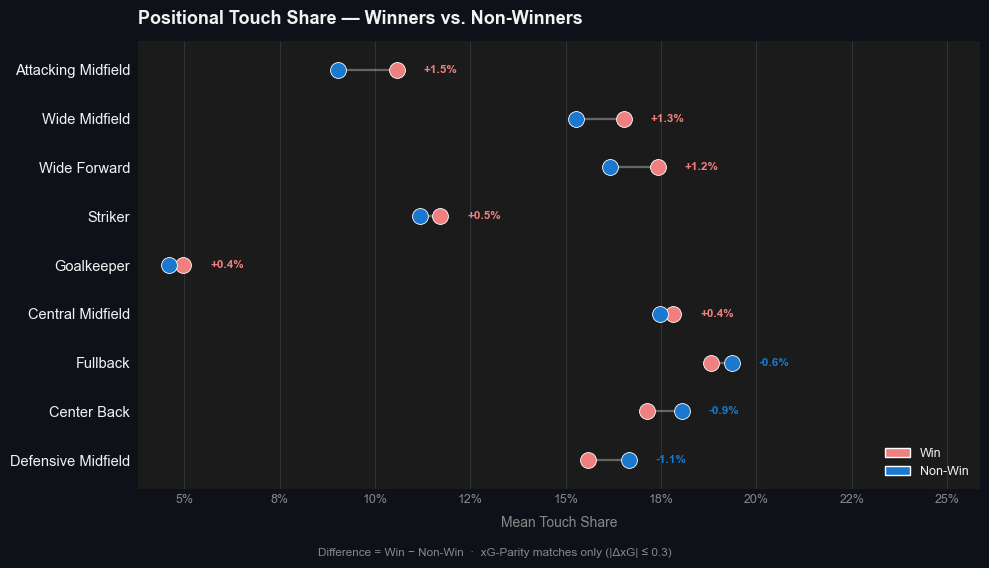

In [67]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Palette ───────────────────────────────────────────────────────────────────
BG_DARK   = "#0E1117"
BG_PANEL  = "#1B1B1B"
CORAL     = "lightcoral"
BLUE      = "#1A78CF"
WHITE     = "#F2F2F2"
GREY      = "#888888"
SPINE_COL = "#2E323A"

# ── Aggregate from touches_pd (computed in Section 2) ─────────────────────────
touch_agg = (
    touches_pd
    .groupby(["position_bin", "outcome_binary"])["touch_share"]
    .mean()
    .unstack()
    .reset_index()
)
touch_agg = touch_agg.rename(columns={"Non-Win": "Non_Win"})
touch_agg["diff"] = touch_agg["Win"] - touch_agg["Non_Win"]
touch_agg = touch_agg.sort_values("diff", ascending=True)

positions = touch_agg["position_bin"].tolist()
n = len(positions)

# ── Figure ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5.5))
fig.patch.set_facecolor(BG_DARK)
ax.set_facecolor(BG_PANEL)

all_x = list(touch_agg["Win"]) + list(touch_agg["Non_Win"])
ax.set_xlim(min(all_x) - 0.008, max(all_x) + 0.065)

ax.grid(axis="x", color=SPINE_COL, lw=0.7, zorder=0)
ax.grid(axis="y", visible=False)
for spine in ax.spines.values():
    spine.set_edgecolor(SPINE_COL)

for i, row in enumerate(touch_agg.itertuples()):
    bw, bn, diff = row.Win, row.Non_Win, row.diff
    ax.plot([bw, bn], [i, i], color=WHITE, lw=1.6, alpha=0.35, zorder=2)
    ax.scatter(bw, i, color=CORAL, s=130, zorder=4, edgecolors="white", linewidths=0.6)
    ax.scatter(bn, i, color=BLUE,  s=130, zorder=4, edgecolors="white", linewidths=0.6)
    sign  = "+" if diff >= 0 else ""
    label = f"{sign}{diff*100:.1f}%"
    col   = CORAL if diff > 0 else (BLUE if diff < 0 else GREY)
    ax.text(max(bw, bn) + 0.007, i, label,
            va="center", ha="left", fontsize=8.5,
            color=col, fontweight="bold", zorder=5)

ax.set_yticks(range(n))
ax.set_yticklabels(positions, color=WHITE, fontsize=10.5)
ax.set_ylim(-0.6, n - 0.4)
ax.tick_params(axis="y", length=0, pad=6)
ax.tick_params(axis="x", colors=GREY, labelsize=9)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_xlabel("Mean Touch Share", color=GREY, fontsize=10, labelpad=7)

ax.set_title(
    "Positional Touch Share — Winners vs. Non-Winners",
    color=WHITE, fontsize=13, fontweight="bold", loc="left", pad=12,
)
fig.text(0.5, -0.02,
    "Difference = Win − Non-Win  ·  xG-Parity matches only (|ΔxG| ≤ 0.3)",
    ha="center", color=GREY, fontsize=8.5)

legend_handles = [
    mpatches.Patch(facecolor=CORAL, edgecolor="white", label="Win"),
    mpatches.Patch(facecolor=BLUE,  edgecolor="white", label="Non-Win"),
]
ax.legend(handles=legend_handles, loc="lower right",
          framealpha=0.15, facecolor=BG_PANEL,
          labelcolor=WHITE, fontsize=9, edgecolor=SPINE_COL)

plt.tight_layout()
plt.show()


## Visualization 2: Progressive Carry Distance — Winners vs. Non-Winners

**What this shows:** Mean progressive carry distance by position for winning and 
non-winning teams, displayed as a diverging bar chart ordered by difference.

**Finding it supports:** Section 3A — winners carry more aggressively in attacking positions.

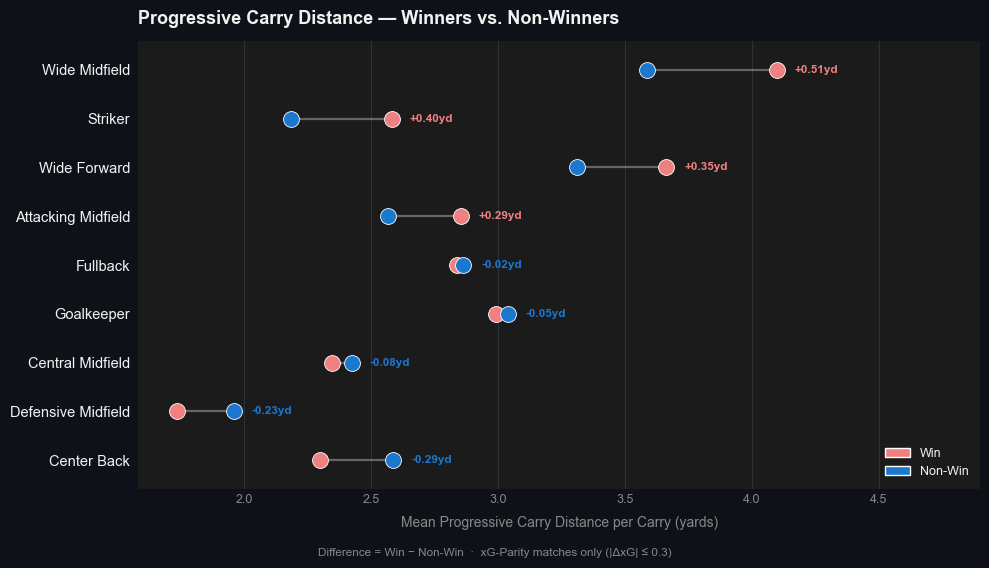

In [68]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Palette ───────────────────────────────────────────────────────────────────
BG_DARK   = "#0E1117"
BG_PANEL  = "#1B1B1B"
CORAL     = "lightcoral"
BLUE      = "#1A78CF"
WHITE     = "#F2F2F2"
GREY      = "#888888"
SPINE_COL = "#2E323A"

# ── Aggregate from carries_pd (computed in Section 3) ─────────────────────────
# carries_pd has: match_id, team, position_bin, mean_prog_distance, outcome, outcome_binary
dist_agg = (
    carries_pd
    .groupby(["position_bin", "outcome_binary"])["mean_prog_distance"]
    .mean()
    .unstack()
    .reset_index()
)
dist_agg = dist_agg.rename(columns={"Non-Win": "Non_Win"})
dist_agg["diff"] = dist_agg["Win"] - dist_agg["Non_Win"]
dist_agg = dist_agg.sort_values("diff", ascending=True)

positions = dist_agg["position_bin"].tolist()
n = len(positions)

# ── Figure ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5.5))
fig.patch.set_facecolor(BG_DARK)
ax.set_facecolor(BG_PANEL)

all_x = list(dist_agg["Win"]) + list(dist_agg["Non_Win"])
ax.set_xlim(min(all_x) - 0.15, max(all_x) + 0.8)

ax.grid(axis="x", color=SPINE_COL, lw=0.7, zorder=0)
ax.grid(axis="y", visible=False)
for spine in ax.spines.values():
    spine.set_edgecolor(SPINE_COL)

for i, row in enumerate(dist_agg.itertuples()):
    bw, bn, diff = row.Win, row.Non_Win, row.diff
    ax.plot([bw, bn], [i, i], color=WHITE, lw=1.6, alpha=0.35, zorder=2)
    ax.scatter(bw, i, color=CORAL, s=130, zorder=4, edgecolors="white", linewidths=0.6)
    ax.scatter(bn, i, color=BLUE,  s=130, zorder=4, edgecolors="white", linewidths=0.6)
    sign  = "+" if diff >= 0 else ""
    label = f"{sign}{diff:.2f}yd"
    col   = CORAL if diff > 0 else (BLUE if diff < 0 else GREY)
    ax.text(max(bw, bn) + 0.07, i, label,
            va="center", ha="left", fontsize=8.5,
            color=col, fontweight="bold", zorder=5)

ax.set_yticks(range(n))
ax.set_yticklabels(positions, color=WHITE, fontsize=10.5)
ax.set_ylim(-0.6, n - 0.4)
ax.tick_params(axis="y", length=0, pad=6)
ax.tick_params(axis="x", colors=GREY, labelsize=9)
ax.set_xlabel("Mean Progressive Carry Distance per Carry (yards)", color=GREY, fontsize=10, labelpad=7)

ax.set_title(
    "Progressive Carry Distance — Winners vs. Non-Winners",
    color=WHITE, fontsize=13, fontweight="bold", loc="left", pad=12,
)
fig.text(0.5, -0.02,
    "Difference = Win − Non-Win  ·  xG-Parity matches only (|ΔxG| ≤ 0.3)",
    ha="center", color=GREY, fontsize=8.5)

legend_handles = [
    mpatches.Patch(facecolor=CORAL, edgecolor="white", label="Win"),
    mpatches.Patch(facecolor=BLUE,  edgecolor="white", label="Non-Win"),
]
ax.legend(handles=legend_handles, loc="lower right",
          framealpha=0.15, facecolor=BG_PANEL,
          labelcolor=WHITE, fontsize=9, edgecolor=SPINE_COL)

plt.tight_layout()
plt.show()


## Visualization 3: Touch Share vs. Progressive Distance — Independence Plot

**What this shows:** Scatter plot of mean touch share vs. mean progressive distance 
by position, with Win and Non-Win shown as separate series.

**Finding it supports:** Section 3B — the two dimensions are independent (Spearman r ≈ 0),
visible as no clear linear relationship across positions.

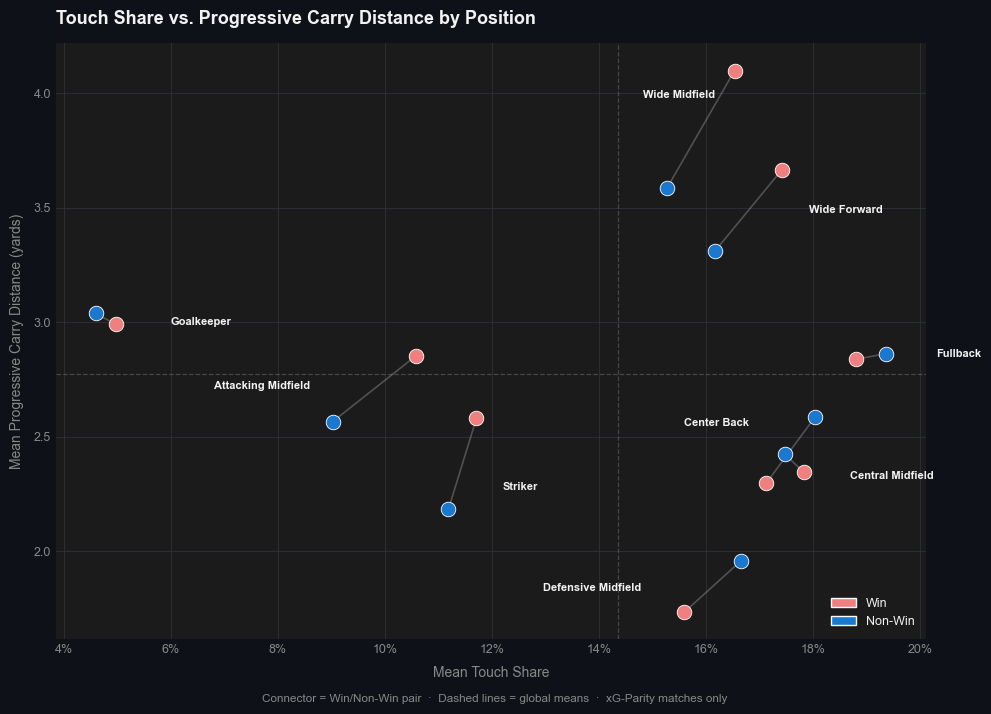

In [69]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Palette ───────────────────────────────────────────────────────────────────
BG_DARK   = "#0E1117"
BG_PANEL  = "#1B1B1B"
CORAL     = "lightcoral"
BLUE      = "#1A78CF"
WHITE     = "#F2F2F2"
GREY      = "#888888"
SPINE_COL = "#2E323A"

# ── Aggregate from touches_pd and carries_pd (computed in Sections 2 & 3) ─────
touch_agg = (
    touches_pd
    .groupby(["position_bin", "outcome_binary"])["touch_share"]
    .mean()
    .reset_index()
)
prog_agg = (
    carries_pd
    .groupby(["position_bin", "outcome_binary"])["mean_prog_distance"]
    .mean()
    .reset_index()
)
scatter_df = touch_agg.merge(prog_agg, on=["position_bin", "outcome_binary"])

wins    = scatter_df[scatter_df["outcome_binary"] == "Win"]
nonwins = scatter_df[scatter_df["outcome_binary"] == "Non-Win"]

# ── Figure ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor(BG_DARK)
ax.set_facecolor(BG_PANEL)

ax.grid(axis="x", color=SPINE_COL, lw=0.6, zorder=0)
ax.grid(axis="y", color=SPINE_COL, lw=0.6, zorder=0)
for spine in ax.spines.values():
    spine.set_edgecolor(SPINE_COL)

ax.axvline(scatter_df["touch_share"].mean(), color=GREY, lw=0.9, ls="--", alpha=0.4, zorder=1)
ax.axhline(scatter_df["mean_prog_distance"].mean(), color=GREY, lw=0.9, ls="--", alpha=0.4, zorder=1)

# ── Per-position connector lines + dots ───────────────────────────────────────
positions = scatter_df["position_bin"].unique()

label_cfg = {
    # (lx, ly, ha, va) — calibrated to touch_share x / carry distance y axes
    "Goalkeeper":          (0.060, 3.00, "left",   "center"),
    "Wide Midfield":       (0.155, 3.97, "center", "bottom"),
    "Wide Forward":        (0.193, 3.49, "right",  "center"),
    "Fullback":            (0.203, 2.86, "left",   "center"),
    "Attacking Midfield":  (0.086, 2.72, "right",  "center"),
    "Center Back":         (0.168, 2.56, "right",  "center"),
    "Central Midfield":    (0.187, 2.33, "left",   "center"),
    "Striker":             (0.122, 2.28, "left",   "center"),
    "Defensive Midfield":  (0.148, 1.84, "right",  "center"),
}

for pos in positions:
    grp = scatter_df[scatter_df["position_bin"] == pos]
    w_row = grp[grp["outcome_binary"] == "Win"]
    n_row = grp[grp["outcome_binary"] == "Non-Win"]
    if w_row.empty or n_row.empty:
        continue

    wx, wy = float(w_row["touch_share"]), float(w_row["mean_prog_distance"])
    nx, ny = float(n_row["touch_share"]), float(n_row["mean_prog_distance"])
    cx, cy = (wx + nx) / 2, (wy + ny) / 2

    ax.plot([wx, nx], [wy, ny], color=WHITE, lw=1.2, alpha=0.25, zorder=2)
    ax.scatter(wx, wy, color=CORAL, s=110, zorder=5, edgecolors="white", linewidths=0.6)
    ax.scatter(nx, ny, color=BLUE,  s=110, zorder=5, edgecolors="white", linewidths=0.6)

    lx, ly, ha, va = label_cfg.get(pos, (cx, cy + 0.1, "center", "bottom"))
    ax.text(lx, ly, pos, ha=ha, va=va,
            color=WHITE, fontsize=8, fontweight="bold", zorder=6)

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.tick_params(axis="x", colors=GREY, labelsize=9)
ax.tick_params(axis="y", colors=GREY, labelsize=9)
ax.set_xlabel("Mean Touch Share", color=GREY, fontsize=10, labelpad=7)
ax.set_ylabel("Mean Progressive Carry Distance (yards)", color=GREY, fontsize=10, labelpad=7)

ax.set_title(
    "Touch Share vs. Progressive Carry Distance by Position",
    color=WHITE, fontsize=13, fontweight="bold", loc="left", pad=14,
)
fig.text(0.5, -0.01,
    "Connector = Win/Non-Win pair  ·  Dashed lines = global means  ·  xG-Parity matches only",
    ha="center", color=GREY, fontsize=8.5)

legend_handles = [
    mpatches.Patch(facecolor=CORAL, edgecolor="white", label="Win"),
    mpatches.Patch(facecolor=BLUE,  edgecolor="white", label="Non-Win"),
]
ax.legend(handles=legend_handles, loc="lower right",
          framealpha=0.15, facecolor=BG_PANEL,
          labelcolor=WHITE, fontsize=9, edgecolor=SPINE_COL)

plt.tight_layout()
plt.show()


---

# Section 4B: Translating Positional Structure into a Predictive Signal

## Question 4: Do the positional patterns we identified actually correlate with winning?

**Context:** Sections 2 and 3 established that winners differ from non-winners in positional 
touch share and progressive carry distance. But statistical significance alone doesn't tell 
us whether these differences have practical predictive value. Here we construct a simple 
Forward Possession Index (FPI), a single score that summarizes a team's positional 
structure, and test whether it separates winners from non-winners.

**Forward Possession Index (FPI):**  
FPI = (Attacking Midfield + Wide Forward touch share) − (Center Back + Defensive Midfield + Fullback touch share)

A positive FPI means a team concentrates possession in advanced positions relative to 
defensive ones. We use only the 5 outfield positions that survived Bonferroni correction 
in Section 2. Goalkeeper touch share, while statistically significant, is excluded here 
to keep the index focused on outfield tactical structure.

**Tests:**
- Mann-Whitney U: Is FPI higher for winners than non-winners?
- AUC: How well does FPI alone discriminate between winners and non-winners?

---

We construct the Forward Possession Index (FPI) by combining the five outfield positions 
that survived Bonferroni correction in Section 2 into a single score. Rather than 
examining positions individually, FPI asks whether the *overall* positional profile of a 
team (how much more they possess in advanced versus defensive areas) carries predictive 
signal for match outcomes. The AUC (Area Under the ROC Curve) measures this directly: 
a value of 0.5 means the index is no better than a coin flip, while 1.0 means perfect 
discrimination. We are not building a model, rather we are testing whether the pattern we 
identified statistically translates into a meaningful signal in practice.

In [19]:
from sklearn.metrics import roc_auc_score

# Pivot touch share to wide format for FPI calculation
touch_wide = (
    touches_pd
    .pivot_table(
        index=['match_id', 'team', 'outcome_binary'],
        columns='position_bin',
        values='touch_share',
        aggfunc='mean'
    )
    .reset_index()
)

# Compute Forward Possession Index (FPI)
attacking = ['Attacking Midfield', 'Wide Forward']
defensive = ['Center Back', 'Defensive Midfield', 'Fullback']

touch_wide['FPI'] = (
    touch_wide[attacking].sum(axis=1) -
    touch_wide[defensive].sum(axis=1)
)

# Mann-Whitney U test on FPI
win_fpi = touch_wide[touch_wide['outcome_binary'] == 'Win']['FPI']
nonwin_fpi = touch_wide[touch_wide['outcome_binary'] == 'Non-Win']['FPI']

u_stat, p_val = mannwhitneyu(win_fpi, nonwin_fpi, alternative='two-sided')
d = cohens_d(win_fpi, nonwin_fpi)

# AUC
y_true = (touch_wide['outcome_binary'] == 'Win').astype(int)
auc = roc_auc_score(y_true, touch_wide['FPI'])

print("Forward Possession Index (FPI) Analysis")
print("=" * 50)
print(f"  Win mean FPI    : {win_fpi.mean():.4f}")
print(f"  Non-Win mean FPI: {nonwin_fpi.mean():.4f}")
print(f"  Difference      : {win_fpi.mean() - nonwin_fpi.mean():.4f}")
print(f"\nMann-Whitney U Test:")
print(f"  U statistic : {u_stat:.1f}")
print(f"  p-value     : {p_val:.4f}")
print(f"  Cohen's d   : {d:.4f}")
print(f"\nPredictive Signal:")
print(f"  AUC         : {auc:.4f}")
print(f"  Interpretation: {'Better than random' if auc > 0.5 else 'No predictive signal'}")

Forward Possession Index (FPI) Analysis
  Win mean FPI    : -0.3418
  Non-Win mean FPI: -0.3753
  Difference      : 0.0334

Mann-Whitney U Test:
  U statistic : 215347.0
  p-value     : 0.0006
  Cohen's d   : 0.2140

Predictive Signal:
  AUC         : 0.5577
  Interpretation: Better than random


### Finding 4: Forward Possession Index Confirms Positional Structure as a Real But Modest Signal

**Statistical Evidence:**
- Mann-Whitney U: U = 215,347, p = 0.0006
- Cohen's d = 0.21 (small effect)
- AUC = 0.558

**Interpretation:**  
The Forward Possession Index, combining the five outfield positions that survived 
Bonferroni correction, is significantly higher for winners than non-winners (p = 0.0006). 
Winners concentrate a greater share of touches in advanced positions relative to defensive 
ones, and this aggregate signal is robust across 1,302 team-match observations.

The AUC of 0.558 deserves careful interpretation. FPI correctly ranks a winner above a 
non-winner approximately 56% of the time, meaningfully better than chance (50%), but 
far from a standalone predictor. This is expected: soccer outcomes in xG-parity matches 
are inherently uncertain, and positional structure is one signal among many. A coin flip 
would be right 50% of the time; FPI moves that needle to 56%.

This finding motivates rather than resolves the analytical question. Positional structure 
carries real signal, enough to justify deeper investigation through tactical archetype 
clustering and multi-dimensional modeling in future work.

**Note on FPI means:** Both Win and Non-Win FPI values are negative (-0.34 and -0.38 
respectively), reflecting that all teams accumulate more touches in defensive and midfield 
positions than attacking ones by virtue of squad composition. The signal lies in the 
*difference* between groups, not the absolute values.

**Decision:** Positional structure confirmed as a modest but real predictive signal  

---

---

# Section 5: Conclusions and Implications

## What We Set Out to Answer

In matches where both teams create nearly equal expected goals, what separates winners 
from non-winners? xG alone cannot answer this question because by definition xG-parity matches 
are those where chance quality does not clearly favor either side. We hypothesized that 
**positional structure**, the how teams distribute possession and move the ball across 
positions, might provide the signal that xG cannot.

---

## What We Found

Through seven statistical tests applied to 651 xG-parity matches (1,302 team-match 
observations), we established the following:

| Section | Question | Test | Result | Interpretation |
|---------|----------|------|--------|----------------|
| 1 | Are parity matches genuinely close? | Chi-square | χ² = 124.48, p < 0.0001 | Draw rate ~30% vs 11% in dominant matches |
| 2A | Do winners differ positionally? | Mann-Whitney U | 7/9 positions significant | Winners shift possession forward |
| 2B | How large are the differences? | Cohen's d | d = 0.05–0.35 | Small but consistent effects |
| 2C | Are results robust? | Bonferroni | 6/9 positions survive | Findings are not statistical noise |
| 3A | Do winners carry more progressively? | Directional summary | 4/9 positions differ | Attacking positions more aggressive |
| 3B | Are the two dimensions independent? | Spearman correlation | r = -0.086, p = 0.735 | Two distinct tactical dimensions |
| 4 | Does positional structure predict wins? | Mann-Whitney + AUC | p = 0.0006, AUC = 0.558 | Real but modest predictive signal |

---

## The Answer

When xG is equal, **positional structure separates winners from non-winners**, but 
modestly. Winners in xG-parity matches exhibit two independent tactical behaviors:

1. **Where they possess:** More touches in attacking positions (Attacking Midfield, 
   Wide Forward) and fewer in defensive positions (Center Back, Defensive Midfield, 
   Fullback) confirmed across 6 of 9 positions after Bonferroni correction.

2. **How they move:** More aggressive progressive carries in attacking positions, 
   more conservative in defensive positions; a pattern independent of touch share 
   (Spearman r ≈ 0).

Together these two dimensions combine into a Forward Possession Index that predicts 
match outcomes better than chance (AUC = 0.558), though soccer's inherent complexity 
means positional structure alone is far from a complete explanation.

---

## Limitations

- **Dataset scope:** StatsBomb open data covers select competitions and seasons, 
  predominantly featuring elite European clubs. Findings may not generalize to all 
  levels of professional soccer.
- **Causality:** We identify correlation, not causation. Winning teams may adopt 
  more aggressive positional structures *because* they are winning (game state effects), 
  not solely as a pre-determined tactical choice.
- **xG threshold:** The 0.3 threshold defining parity is analytically motivated but 
  not uniquely validated as Section 1 showed draw rates are similar across the 0–0.7 
  range.
- **FPI simplicity:** The Forward Possession Index is a linear combination of five 
  positions. A more sophisticated model incorporating interactions, progressive distance, 
  and game state would likely improve predictive power.

---

## Implications and Next Steps

This analysis establishes that positional structure carries a real tactical signal in 
xG-parity matches. The natural next step is to move from aggregate differences to 
**tactical archetypes** clustering team-match observations by their positional profiles 
to identify distinct styles of play and test whether certain archetypes win more 
consistently than others.

Planned future work:
- **Clustering:** Identify tactical archetypes from positional touch share and 
  progressive distance profiles
- **Archetype outcomes:** Test whether archetype membership predicts wins 
  (Chi-square, logistic regression)
- **Generalization:** Validate findings on a temporal holdout sample

---

## Statistical Rigor Summary

This analysis applied seven distinct statistical tests, each serving a specific purpose:
- **Existence:** Mann-Whitney U (non-parametric, appropriate for bounded distributions)
- **Magnitude:** Cohen's d (effect size beyond p-values)
- **Robustness:** Bonferroni correction (multiple testing adjustment)
- **Independence:** Spearman correlation (non-parametric association)
- **Predictive value:** AUC (discrimination ability without model assumptions)

No single test tells the complete story. The convergence of evidence across multiple 
methods, each answering a different aspect of the same question, is what gives these 
findings their credibility.

---

*This notebook serves as the analytical foundation for Team 4's Georgia Tech MSA Spring 
2026 Practicum final deliverable. Full code, data pipeline, and reproducibility 
instructions are available in the project repository.*